# Scores vs probabilidades  
## Cuando una predicción correcta no es confiable

### Objetivo del notebook
Demostrar, mediante un experimento controlado, que un modelo puede tener
**alta precisión** y aun así producir **probabilidades engañosas**.

El foco no está en mejorar métricas, sino en entender:
- la diferencia entre *score* y *probabilidad*,
- por qué una probabilidad es una **estimación**,
- y cómo aparece el **overconfidence** incluso en modelos aparentemente buenos.

Este notebook introduce los conceptos fundamentales que justifican
la necesidad de medir y corregir la confianza en modelos de Machine Learning.

## Conceptos que se van a definir hoy

A lo largo de este notebook, los siguientes conceptos se introducirán
**de forma progresiva**, siempre ligados a un experimento concreto:

- **Predicción**  
  Resultado que entrega un modelo (clase o valor), no una decisión.

- **Score**  
  Salida numérica cruda del modelo antes de cualquier transformación
  probabilística.

- **Probabilidad**  
  Transformación del score a un rango interpretable \([0, 1]\).  
  No es un hecho, es una **estimación**.

- **Estimación**  
  Aproximación basada en datos y supuestos del modelo.  
  Puede ser correcta o incorrecta incluso cuando la predicción acierta.

- **Overconfidence**  
  Situación en la que el modelo asigna alta probabilidad a predicciones
  que resultan ser erróneas.

- **Reproducibilidad**  
  Capacidad de repetir un experimento y obtener los mismos resultados,
  condición necesaria para extraer conclusiones técnicas válidas.

Estos conceptos no se definen de forma abstracta:  
cada uno aparecerá cuando el código lo haga evidente.

---

## Imports y carga de utilidades comunes

### ¿Qué vamos a hacer?
Vamos a importar las librerías necesarias para este experimento y
cargar las utilidades definidas en el notebook de setup.

### ¿Por qué importa?
- Mantener imports explícitos evita dependencias ocultas.
- Reutilizar utilidades garantiza que todas las métricas y gráficos
  se calculen de la misma forma en todo el laboratorio.
- Separar setup de experimento es disciplina básica de ingeniería.

In [1]:
# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Modelos y métricas
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Cargar utilidades del setup
# Ajusta la ruta si tu entorno lo requiere
from importlib import reload
import sys

sys.path.append("../00_setup")

from environment_and_utils import (
    brier_score,
    expected_calibration_error,
    plot_reliability_diagram,
)

## Generación de datos sintéticos

### ¿Qué vamos a hacer?
Vamos a generar un dataset binario **sintético** para tener control total del experimento:
- separabilidad entre clases,
- nivel de ruido,
- y grado de solapamiento.

### ¿Por qué importa?
En esta etapa buscamos entender el fenómeno (scores, probabilidades y overconfidence) sin ruido externo.
Los datos sintéticos permiten **provocar** situaciones donde el modelo puede acertar mucho y aun así ser poco confiable.

### Conceptos que se definen aquí
- **Datos sintéticos**: datos generados artificialmente para controlar el problema.
- **Ruido**: etiquetas o patrones “sucios” que dificultan el aprendizaje.
- **Solapamiento**: regiones donde ambas clases se mezclan (zona gris).
- **Train/Test split**: separación para evaluar generalización.

In [2]:
# Generación de dataset sintético (clasificación binaria)
X, y = make_classification(
    n_samples=4000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_clusters_per_class=2,
    class_sep=1.0,        # separabilidad moderada
    flip_y=0.05,          # 5% de ruido en etiquetas
    random_state=42
)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((2800, 10), (1200, 10))

In [3]:
df_X_train = pd.DataFrame(X_train)

# Mostrar las primeras filas
df_X_train.head()

,0,1,2,3,4,5,6,7,8,9
0,-0.595770,-1.432866,0.921850,-0.862824,2.062104,0.141233,-1.312649,-0.723770,-2.404444,0.076569
1,-0.537556,0.226639,1.043936,1.405790,-4.076748,-0.872960,-0.518890,3.131012,3.193546,-3.242767
2,0.903708,-0.541557,0.299369,0.225349,0.930324,-0.966035,0.530502,-0.570426,-0.445381,0.793469
3,0.842612,-0.624665,-0.483601,0.548130,-3.348163,0.296536,-0.369409,2.750180,2.175329,-3.984629
4,2.780242,-0.582571,2.049709,-0.777756,0.238777,-0.446162,-0.019279,0.044968,-0.500758,-1.091954


In [4]:
df_X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       2800 non-null   float64
 1   1       2800 non-null   float64
 2   2       2800 non-null   float64
 3   3       2800 non-null   float64
 4   4       2800 non-null   float64
 5   5       2800 non-null   float64
 6   6       2800 non-null   float64
 7   7       2800 non-null   float64
 8   8       2800 non-null   float64
 9   9       2800 non-null   float64
dtypes: float64(10)
memory usage: 218.9 KB


In [5]:
df_X_test = pd.DataFrame(X_test)

# Mostrar las primeras filas
df_X_test.head()

,0,1,2,3,4,5,6,7,8,9
0,-0.619209,0.598972,-0.430331,0.475147,0.716782,-0.318351,-1.013476,0.328811,-0.455651,1.328529
1,-1.357715,-1.300640,-0.067672,-0.759551,1.868602,0.013229,-0.159684,0.958141,-2.944724,-0.695239
2,2.106169,1.110719,-1.541251,-2.651185,0.400491,-2.020595,-0.992310,-1.614440,-0.891027,-0.606954
3,3.521517,1.978557,1.511189,-0.175437,0.620188,-0.024861,0.137139,2.912120,-1.155271,0.301104
4,-2.212712,-2.234479,1.507644,0.193870,1.589494,0.613495,-0.015982,-0.265587,-1.840680,-0.091817


In [6]:
df_X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1200 non-null   float64
 1   1       1200 non-null   float64
 2   2       1200 non-null   float64
 3   3       1200 non-null   float64
 4   4       1200 non-null   float64
 5   5       1200 non-null   float64
 6   6       1200 non-null   float64
 7   7       1200 non-null   float64
 8   8       1200 non-null   float64
 9   9       1200 non-null   float64
dtypes: float64(10)
memory usage: 93.9 KB


## Parámetros del dataset sintético (`make_classification`)

- **n_samples**  
  Número total de observaciones (filas) del dataset.

- **n_features**  
  Número total de variables (columnas) por observación.

- **n_informative**  
  Cantidad de variables que realmente contienen información útil para separar las clases.

- **n_redundant**  
  Variables que son combinaciones lineales de las informativas  
  (información duplicada o correlacionada).

- **n_clusters_per_class**  
  Número de subgrupos internos por cada clase.

- **class_sep**  
  Nivel de separación entre las clases.  
  Valores bajos generan solapamiento; valores altos hacen el problema más fácil.

- **flip_y**  
  Porcentaje de etiquetas asignadas incorrectamente de forma aleatoria  
  (ruido en los datos).

- **random_state**  
  Semilla para que la generación del dataset sea reproducible.

---

## División de datos (`train_test_split`)

- **test_size**  
  Proporción del dataset reservada para evaluación.

- **stratify**  
  Mantiene la misma proporción de clases en entrenamiento y prueba.


---

## Entrenar 2 modelos (baseline vs modelo flexible)

### ¿Qué vamos a hacer?
Vamos a entrenar dos modelos simples para comparar comportamientos:

1. **Logistic Regression**: modelo lineal, suele ser un baseline razonable.
2. **Decision Tree**: modelo flexible, puede sobreajustar y generar confianza extrema.

### ¿Por qué importa?
El objetivo no es “ganar accuracy”, sino observar cómo distintos modelos:
- separan clases,
- y producen probabilidades con diferentes niveles de confiabilidad.

### Conceptos que se definen aquí
- **Baseline**: modelo simple para referencia.
- **Modelo flexible**: puede capturar patrones complejos, pero también exagerar certeza.
- **Generalización**: desempeño en datos no vistos (test).

---
---

# Entrenamiento de modelos

## Regresión Logística

### ¿Qué vamos a hacer?
Vamos a entrenar un modelo de **Regresión Logística** sobre el dataset sintético y evaluar su desempeño básico.

En esta etapa:
- no ajustamos hiperparámetros,
- no optimizamos métricas,
- y no hablamos aún de calibración.

El objetivo es **observar el comportamiento base** de un modelo lineal que suele usarse como referencia.

---

### ¿Por qué este modelo?
La Regresión Logística es un baseline común en clasificación binaria porque:
- es simple,
- es interpretable,
- y suele producir probabilidades relativamente razonables.

Por estas razones, se utiliza como punto de comparación para modelos más complejos.

---

### Qué vamos a observar
Nos enfocaremos en:
- el nivel de accuracy en datos de prueba,
- si el modelo generaliza razonablemente,
- y qué expectativas iniciales podemos tener sobre sus probabilidades.

Estas observaciones son **intuitivas**, no métricas profundas todavía.

---

### Nota importante
En este punto **una buena accuracy no implica que el modelo sea confiable**.  
Solo estamos estableciendo un punto de partida para comparaciones posteriores.


### Paso 1 — Entrenar el modelo

Aquí entrenamos la Regresión Logística usando el conjunto de entrenamiento.
La idea es construir un baseline simple, sin tuning.

In [7]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Paso 2 — Generar predicciones en el conjunto de prueba

Ahora usamos el modelo entrenado para predecir clases (0/1) en `X_test`.
Esto nos permitirá calcular accuracy como primer indicador.

In [8]:
y_pred_lr = log_reg.predict(X_test)

### Paso 3 — Calcular accuracy (evaluación básica)

Calculamos accuracy en el conjunto de prueba.
Esto NO mide confiabilidad de probabilidades; solo mide aciertos de clase.

In [9]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_lr

0.7908333333333334

### Paso 4 — Interpretación inicial (sin calibración todavía)

En esta etapa solo hacemos una lectura básica:
- ¿El baseline generaliza razonablemente?
- ¿La accuracy es suficientemente alta como para que el “problema de confianza” sea relevante?

### Observaciones iniciales — Regresión Logística

La Regresión Logística obtiene una accuracy cercana al **79%** en el conjunto de prueba.

Esto indica que:
- el modelo generaliza razonablemente,
- el problema no es trivial,
- y existe una proporción relevante de errores.

Desde el punto de vista operativo, este nivel de accuracy es suficiente para que:
- el modelo pueda parecer “útil”,
- y sus probabilidades comiencen a usarse para tomar decisiones.

Sin embargo, en esta etapa **no sabemos nada aún** sobre:
- qué tan confiables son esas probabilidades,
- ni si los errores ocurren con baja o alta confianza.

Esto prepara el escenario para el siguiente análisis:
entender si un modelo que acierta ~8 de cada 10 veces
puede aun así **mentir con seguridad**.

---
---

## Árbol de decisión

### ¿Qué vamos a hacer?
Vamos a entrenar un **Árbol de Decisión** sobre el mismo dataset sintético y evaluar su desempeño básico.

Al igual que antes:
- no ajustamos hiperparámetros finos,
- no optimizamos métricas,
- y no analizamos aún probabilidades.

El objetivo es observar cómo se comporta un modelo **más flexible** frente al mismo problema.


### ¿Por qué este modelo?
El Árbol de Decisión:
- puede capturar relaciones no lineales,
- se adapta rápidamente a los datos,
- y tiende a generar predicciones muy seguras.

Estas características lo convierten en un buen candidato para estudiar
**overconfidence**, incluso cuando la accuracy es similar a la de un baseline.

### Paso 1 — Entrenar el modelo
Entrenamos un Árbol de Decisión con profundidad limitada para evitar
un sobreajuste extremo, pero manteniendo flexibilidad.

In [10]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### Paso 2 — Generar predicciones en el conjunto de prueba
Usamos el árbol entrenado para predecir clases en `X_test`.

In [11]:
y_pred_tree = tree.predict(X_test)

### Paso 3 — Calcular accuracy (evaluación básica)
Calculamos accuracy para comparar con la Regresión Logística.

In [12]:
acc_tree = accuracy_score(y_test, y_pred_tree)
acc_tree

0.8608333333333333

### Paso 4 — Interpretación inicial (sin probabilidades todavía)

Aquí solo observamos:
- si el árbol mejora o no la accuracy,
- si parece más “potente” que el baseline,
- y qué expectativas intuitivas genera.

### Observaciones iniciales — Árbol de decisión

El Árbol de Decisión obtiene una accuracy cercana al **86%**, superior a la obtenida por la Regresión Logística.

Esto sugiere que:
- el modelo es más flexible,
- captura mejor la estructura del dataset,
- y comete menos errores de clasificación.

Desde una mirada superficial, este modelo podría considerarse
**claramente mejor** que el baseline.

Sin embargo, esta mejora en accuracy viene con una advertencia implícita:
los modelos más flexibles suelen producir predicciones **más extremas**,
lo que puede traducirse en probabilidades muy altas incluso en casos dudosos.

En este punto aún no sabemos:
- si esa mayor precisión viene acompañada de probabilidades confiables,
- o si el modelo es más propenso al overconfidence.

Esto convierte al Árbol de Decisión en un excelente candidato
para estudiar el problema de la confianza en las siguientes secciones.

---
---

## Comparación inicial entre modelos

### ¿Qué vamos a hacer?
Vamos a comparar **Regresión Logística** y **Árbol de Decisión** usando únicamente
la métrica de accuracy.

Esta comparación es deliberadamente incompleta.

---

### ¿Por qué hacerlo así?
En la práctica, muchos sistemas y equipos:
- comparan modelos solo por accuracy,
- eligen el que “gana”,
- y asumen que sus probabilidades son igualmente confiables.

Este paso reproduce esa forma de pensar de manera controlada.

---

### Qué conclusión preliminar se podría sacar
Basándonos solo en accuracy:
- el Árbol de Decisión parece claramente superior,
- y sería el candidato natural para producción.

Esta conclusión es **intuitiva**, pero aún no está justificada.

---

### Qué queda pendiente
En las siguientes secciones vamos a cuestionar esta decisión
analizando:
- scores,
- probabilidades,
- y casos de alta confianza errónea.

El objetivo es demostrar que **predecir mejor no implica confiar mejor**.


---
---

## Scores vs probabilidades

### ¿Qué vamos a hacer?
Vamos a inspeccionar las **salidas internas** de cada modelo:
- el **score** (salida cruda del modelo),
- y la **probabilidad** resultante tras la transformación.

### ¿Por qué importa?
Muchos sistemas tratan la probabilidad como un hecho.
Aquí veremos que es solo una **transformación matemática del score**,
y que esa transformación puede inducir **falsa certeza**.


---

### Regresión Logística — scores y probabilidades

La Regresión Logística produce:
- un **score** (logit) vía `decision_function`,
- una **probabilidad** vía `predict_proba`.

In [13]:
# Scores (logits)
scores_lr = log_reg.decision_function(X_test)
scores_lr[:5]

array([ 0.25314061,  0.62914027, -1.81831229, -0.93894457,  1.02159377])

Cada número del array corresponde a **un caso distinto del conjunto de prueba**.  
Es decir, el modelo analiza cada fila de datos por separado y emite un número para cada una.

En este problema el modelo solo puede elegir entre **dos clases**:
- **clase 0** → lo que llamamos “negativo”
- **clase 1** → lo que llamamos “positivo”

Estas palabras no tienen un significado especial; son solo **etiquetas** para diferenciar dos grupos.

Ahora, qué significa cada número:

- **0.253** → el modelo cree que este caso pertenece a la clase 1, pero sin mucha seguridad.  
- **0.629** → el modelo está más convencido de que este caso es de la clase 1.  
- **-1.818** → el modelo está bastante seguro de que este caso es de la clase 0.  
- **-0.939** → también cree que es de la clase 0, pero con menos seguridad que el anterior.  
- **1.022** → el modelo está bastante seguro de que este caso es de la clase 1.

Dicho de forma sencilla:  
el modelo primero decide **hacia qué grupo se inclina** (clase 0 o clase 1)  
y luego indica **qué tan seguro está** de esa inclinación.

Este número todavía **no es una probabilidad**.  
Es solo una señal interna del modelo que más adelante se transformará en un valor entre 0 y 1.

In [14]:
# Probabilidades
probs_lr = log_reg.predict_proba(X_test)[:, 1]
probs_lr[:5]

array([0.56294936, 0.6522945 , 0.13963651, 0.28111358, 0.73528293])

Estos valores son las **probabilidades** que el modelo asigna a cada caso de pertenecer a la **clase 1**.

De nuevo, cada número corresponde a **un caso distinto del conjunto de prueba**  
(y aquí solo estamos viendo los primeros 5).

Qué significa cada uno, en palabras simples:

- **0.56** → el modelo cree que hay un 56% de probabilidad de que este caso sea de la clase 1.  
- **0.65** → aquí el modelo está un poco más confiado: 65% de probabilidad de clase 1.  
- **0.14** → el modelo cree que es poco probable que sea clase 1; se inclina claramente por la clase 0.  
- **0.28** → sigue pensando que es más probable clase 0, pero con menos seguridad que el anterior.  
- **0.74** → el modelo está bastante convencido de que este caso es de la clase 1.

En términos simples:  
ahora el modelo está expresando su “opinión” en un lenguaje más humano, de **0 a 1**.

Lo importante es entender que:
estas probabilidades **no salen de la nada**;  
son el resultado de transformar los números anteriores (los scores)  
en valores que *parecen* fáciles de interpretar.

Y aquí empieza el punto clave del laboratorio:  
que una probabilidad suene razonable **no significa que sea confiable**.

### Conclusión — scores vs probabilidades

Un **score** es la salida interna del modelo.  
Es una señal cruda que indica **hacia qué clase se inclina** el modelo y **qué tan fuerte es esa inclinación**.  
No está pensada para ser interpretada directamente por humanos.

Una **probabilidad** es el resultado de transformar ese score a un rango entre 0 y 1,  
con la intención de hacerlo más fácil de interpretar y usar para tomar decisiones.

Al comparar los resultados observados:
- vemos que scores relativamente pequeños ya se convierten en probabilidades “razonables” (0.6, 0.7),
- y scores negativos se transforman en probabilidades bajas que parecen seguras (0.14, 0.28).

Esto nos dice algo importante:  
la probabilidad **suaviza** la señal del score y la presenta como un número que parece preciso y confiable,  
aunque en realidad sigue siendo solo una **estimación** basada en el modelo.

En otras palabras, el modelo pasa de decir  
“me inclino un poco por esta clase”  
a decir  
“hay un 65% de probabilidad”.

Esta diferencia es clave, porque crea la ilusión de certeza.  

---
---

### Árbol de Decisión — probabilidades

El Árbol de Decisión no expone logits.
Sus probabilidades provienen de **frecuencias en hojas**,
lo que suele generar valores extremos (0 o 1).

In [15]:
probs_tree = tree.predict_proba(X_test)[:, 1]
probs_tree[:5]

array([0.77021277, 0.77021277, 0.87209302, 0.12655801, 0.89677419])

### Interpretación — probabilidades del Árbol de Decisión

Estos valores son las **probabilidades** que el Árbol de Decisión asigna a cada caso de pertenecer a la clase 1.

A diferencia de la Regresión Logística, aquí ocurre algo distinto:
el árbol **no transforma un score continuo**, sino que calcula probabilidades
en función de cuántos ejemplos de cada clase caen en la misma hoja.

Qué nos dicen estos números:

- **0.77** y **0.77** → dos casos distintos reciben exactamente la misma probabilidad,
  porque terminaron en la **misma hoja** del árbol.
- **0.87** y **0.90** → el modelo se muestra muy seguro de que estos casos son de la clase 1.
- **0.13** → el modelo está muy seguro de que este caso es de la clase 0.

Esto nos revela una característica clave del Árbol de Decisión:
tiende a producir probabilidades **concentradas y extremas**, no graduales.

En términos simples:
el árbol no “duda mucho”.  
Cuando toma una decisión, suele hacerlo con números altos o bajos.

Esto explica por qué el Árbol puede tener mayor accuracy
y al mismo tiempo ser más propenso al **overconfidence**,

---
---

### Distribución de probabilidades

Comparamos visualmente cómo cada modelo distribuye sus probabilidades.
Buscamos señales de **certeza extrema**.

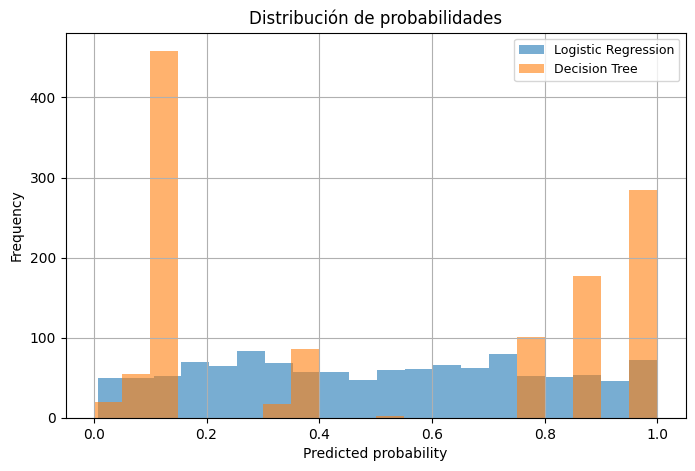

In [16]:
plt.hist(probs_lr, bins=20, alpha=0.6, label="Logistic Regression")
plt.hist(probs_tree, bins=20, alpha=0.6, label="Decision Tree")
plt.xlabel("Predicted probability")
plt.ylabel("Frequency")
plt.legend()
plt.title("Distribución de probabilidades")
plt.show()

### Observaciones — Scores vs probabilidades

- **¿Qué modelo produce probabilidades más extremas?**  
  El **Árbol de Decisión**. Sus probabilidades se concentran claramente en valores muy bajos (cerca de 0) y muy altos (cerca de 1).

- **¿Ves concentraciones cerca de 0 o 1?**  
  Sí, de forma muy marcada en el Árbol de Decisión. La Regresión Logística, en cambio, distribuye sus probabilidades de manera más gradual a lo largo del rango.

- **¿Cuál modelo “parece” más seguro de sí mismo?**  
  El Árbol de Decisión. Visualmente “habla en absolutos”, mientras que la Regresión Logística muestra más matices y dudas.

En términos simples:  
el Árbol de Decisión **parece más confiado**, pero esa confianza es rígida y repetitiva (misma probabilidad para muchos casos).  
La Regresión Logística **parece menos segura**, pero expresa mejor los distintos grados de duda.

Esta diferencia visual es clave: aquí todavía no sabemos cuál es más confiable,  
solo cuál **se muestra** más seguro de sí mismo.

---
---

## Casos peligrosos: alta confianza + error

### ¿Qué vamos a hacer?
Vamos a identificar predicciones en las que el modelo:
- asigna **alta probabilidad** a una clase,
- pero **se equivoca**.

Estos casos son los más riesgosos en sistemas automatizados.

---

### ¿Por qué importa?
Un error con baja confianza suele ser tolerable.
Un error con **alta confianza** genera falsas certezas y malas decisiones.

Aquí no evaluamos cuántos errores hay,
sino **cómo de seguros estaban los modelos cuando fallaron**.

### Definir alta confianza

Para este experimento consideramos “alta confianza”:
- probabilidad ≥ 0.9

Este umbral es arbitrario, pero intuitivo:
representa casos donde el modelo “está muy seguro”.

---

### Regresión Logística — errores con alta confianza

Buscamos casos donde:
- la probabilidad ≥ 0.9,
- pero la predicción es incorrecta.


In [17]:
# Alta confianza según el umbral
high_conf_lr = probs_lr >= 0.9

# Errores
errors_lr = y_pred_lr != y_test

# Casos peligrosos
danger_lr = high_conf_lr & errors_lr

danger_lr.sum()

np.int64(5)

In [18]:
# Ejemplos concretos
pd.DataFrame({
    "y_true": y_test[danger_lr],
    "y_pred": y_pred_lr[danger_lr],
    "probability": probs_lr[danger_lr]
}).head()

,y_true,y_pred,probability
0,0,1,0.926692
1,0,1,0.992988
2,0,1,0.986116
3,0,1,0.988914
4,0,1,0.909428


### Interpretación — Regresión Logística: errores con alta confianza

La Regresión Logística comete **5 errores** en los que el modelo estaba
**muy seguro** (probabilidad ≥ 0.9) y aun así se equivocó.

Qué nos dicen los ejemplos:

- En todos los casos, el valor real (**y_true**) es 0,
  pero el modelo predijo 1 (**y_pred**).
- Las probabilidades son muy altas (0.91–0.99),
  lo que significa que el modelo estaba **convencido** de su decisión.

En palabras simples:
el modelo dijo *“esto es casi seguro clase 1”*  
cuando en realidad pertenecía a la clase 0.

Esto revela un punto clave:
aunque la Regresión Logística no suele parecer extrema,
**sí puede cometer errores graves con mucha seguridad**.

Estos casos son peligrosos porque:
- no invitan a la duda,
- no disparan revisión,
- y pueden llevar a decisiones automáticas incorrectas.

---

### Árbol de Decisión — errores con alta confianza

Repetimos exactamente el mismo análisis para el Árbol de Decisión.


In [19]:
high_conf_tree = probs_tree >= 0.9
errors_tree = y_pred_tree != y_test

danger_tree = high_conf_tree & errors_tree

danger_tree.sum()

np.int64(17)

In [20]:
pd.DataFrame({
    "y_true": y_test[danger_tree],
    "y_pred": y_pred_tree[danger_tree],
    "probability": probs_tree[danger_tree]
}).head()

,y_true,y_pred,probability
0,0,1,0.953488
1,0,1,0.953488
2,0,1,0.968571
3,0,1,0.968571
4,0,1,0.953488


### Interpretación — Árbol de Decisión: errores con alta confianza

El Árbol de Decisión comete **17 errores** en los que el modelo estaba
**muy seguro** (probabilidad ≥ 0.9) y aun así se equivocó.

Qué nos muestran los resultados:

- En todos los casos, el valor real (**y_true**) es 0,
  pero el modelo predijo 1 (**y_pred**).
- Las probabilidades son extremadamente altas (≈0.95–0.97),
  lo que indica una **confianza casi absoluta**.

Un detalle importante:
vemos **probabilidades repetidas** (por ejemplo 0.953488, 0.968571),
lo que significa que muchos casos distintos terminaron en la **misma hoja**
del árbol y recibieron exactamente la misma confianza.

En palabras simples:
el Árbol de Decisión dijo *“estoy casi 100% seguro”*  
muchas más veces… y se equivocó muchas más veces.

Esto refuerza una idea clave:
el Árbol de Decisión **parece** más preciso por su mayor accuracy,
pero también es **más peligroso** porque se equivoca
con mayor frecuencia **cuando está muy seguro**.

### Conclusión — Comparación entre modelos

Aunque el Árbol de Decisión obtiene una **accuracy mayor** que la Regresión Logística,
también comete **más errores con alta confianza**.

La Regresión Logística:
- se equivoca menos veces estando muy segura,
- y expresa la confianza de forma más gradual.

El Árbol de Decisión:
- parece más potente,
- pero genera más falsas certezas,
- y repite niveles altos de confianza incluso cuando se equivoca.

La lección clave es clara:
**un modelo puede predecir mejor y aun así ser menos confiable**.

Por eso, elegir modelos solo por accuracy
puede introducir riesgos invisibles en sistemas automatizados.

---
---

## Métricas de confianza (sin calibrar)

### ¿Qué vamos a hacer?
Vamos a **cuantificar** lo que ya observamos visual y cualitativamente
usando dos métricas clave de confiabilidad:

- **Brier Score**
- **Expected Calibration Error (ECE)**

Aquí **no corregimos** probabilidades. Solo medimos.


---

### Brier Score

El Brier Score mide el error cuadrático entre la probabilidad predicha
y el resultado real.

- Valores más bajos indican probabilidades más confiables.
- Penaliza fuertemente errores con alta confianza.

In [21]:
brier_lr = brier_score(y_test, probs_lr)
brier_tree = brier_score(y_test, probs_tree)

brier_lr, brier_tree

(0.15512626978669714, 0.11472569699811466)

### Análisis — Brier Score

El **Brier Score** mide qué tan lejos están las probabilidades del resultado real.
Cuanto **más bajo**, mejor.

En este caso:
- **Regresión Logística:** 0.155  
- **Árbol de Decisión:** 0.115  

Esto nos dice que, en promedio, el Árbol de Decisión **acierta mejor sus probabilidades** que la Regresión Logística.

En palabras simples:
aunque el Árbol se equivoca más veces con alta confianza,
cuando miramos **el promedio de todos los casos**,
sus probabilidades están más cerca de la realidad.

Esto es importante porque muestra que:
una métrica promedio puede **ocultar errores graves**,
especialmente aquellos pocos casos donde el modelo se equivoca con mucha seguridad.

Conclusión parcial:
el Brier Score favorece al Árbol,
pero **no nos cuenta toda la historia** sobre el riesgo del modelo.

---

### Expected Calibration Error (ECE)

El ECE mide cuánto se desvían, en promedio, las probabilidades
de la frecuencia real observada.

- Valores cercanos a 0 indican buena calibración.
- Valores altos indican overconfidence o underconfidence.

In [22]:
ece_lr = expected_calibration_error(y_test, probs_lr, n_bins=10)
ece_tree = expected_calibration_error(y_test, probs_tree, n_bins=10)

ece_lr, ece_tree

(0.05966844601091286, 0.02209830853948833)

### Análisis — Expected Calibration Error (ECE)

El **ECE** mide qué tan alineadas están las probabilidades del modelo
con lo que realmente ocurre.  
Cuanto **más cerca de 0**, mejor calibrado está el modelo.

En este caso:
- **Regresión Logística:** 0.060  
- **Árbol de Decisión:** 0.022  

Esto indica que, en promedio, las probabilidades del Árbol de Decisión
están **más cerca de la realidad** que las de la Regresión Logística.

Dicho de forma sencilla:
cuando el Árbol dice “70%”, “80%” o “90%”,  
esos números suelen coincidir mejor con lo que pasa de verdad,
si miramos el comportamiento agregado.

Sin embargo, este resultado también tiene una trampa:
el ECE es una **medida promedio** y no distingue bien
los casos extremos donde el modelo se equivoca con mucha seguridad.

Conclusión parcial:
el Árbol parece mejor calibrado según ECE,
pero esto no elimina el riesgo de errores graves con alta confianza
que ya observamos.

---
---
---

## Cierre del Día 1 — Qué nos mostró realmente este experimento

En este día comparamos dos modelos sobre el mismo problema:
una **Regresión Logística** y un **Árbol de Decisión**.

Si miramos solo métricas tradicionales, el Árbol de Decisión parece mejor:
- obtiene mayor accuracy,
- y mejores métricas promedio como Brier Score y ECE.

Sin embargo, al analizar los errores con más detalle apareció el punto clave.

El Árbol de Decisión comete **más errores con alta confianza**:
17 casos en los que asignó probabilidades ≥ 0.9 y aun así se equivocó.
Es decir, más veces dijo *“estoy muy seguro”* cuando no debía.

La Regresión Logística, en cambio, solo presentó **5 errores con alta confianza**.
Aunque se equivoca, tiende a expresar su incertidumbre de forma más gradual
y es menos propensa a falsas certezas extremas.

Esto deja una lección central:

> El riesgo no está solo en cuántas veces un modelo se equivoca,  
> sino en **qué tan seguro está cuando se equivoca**.

Durante el análisis también quedó claro que:
- el **score** es una señal interna del modelo,
- la **probabilidad** es una transformación que puede generar ilusión de certeza,
- y la **accuracy** no captura el riesgo operativo de una decisión automática.

Al finalizar este día no hemos aprendido a corregir el problema,
pero sí a **identificarlo con claridad y medirlo**.

Eso cambia la forma de evaluar modelos:
ya no basta con preguntar *“¿qué modelo acierta más?”*,
sino *“¿qué modelo se equivoca con mayor seguridad?”*.

Ese será el punto de partida del **Día 2**,
donde abordaremos técnicas para **calibrar probabilidades**
y reducir el overconfidence.